In [1]:
# ゲート付きRNN
# RNNの問題点
# RNNの復習
# 勾配消失、勾配爆発
# 勾配消失、勾配爆発の原因

In [6]:
# 逆伝播の際の勾配の値の変化
import numpy as np
import matplotlib.pyplot as plt

rng = np.random.default_rng()

N = 2 # ミニバッチサイズ
H = 3 # 隠れ状態ベクトルの次元数
T = 20 # 時系列データの長さ

dh = np.ones((N, H))
np.random.seed(3) # 再現性のため乱数のシードを固定
Wh = rng.random((H, H)) * 0.5

norm_list = []
for t in range(T):
    dh = dh @ Wh.T
    norm = np.sqrt(np.sum(dh**2)) / N
    norm_list.append(norm)

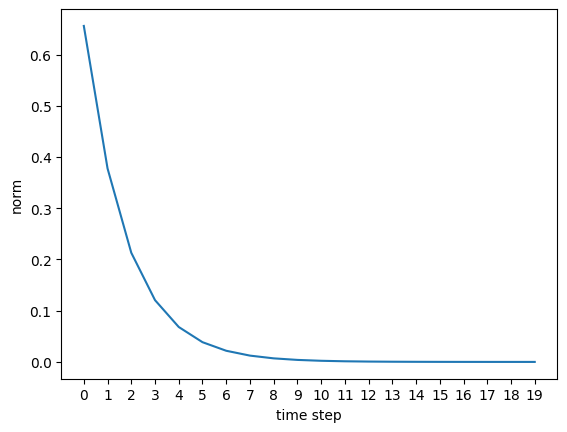

In [7]:
# グラフに表示してみる
plt.plot(np.arange(len(norm_list)), norm_list)
plt.xticks(np.arange(len(norm_list)))
plt.xlabel("time step")
plt.ylabel("norm")
plt.show()

In [10]:
# 勾配爆発への対策
# 勾配クリッピング
import numpy as np

rng = np.random.default_rng()

dW1 = rng.random((3, 3)) * 10
dW2 = rng.random((3, 3)) * 10
grads = [dW1, dW2]
max_norm = 5.0

def clip_grads(grads, max_norm):
    total_norm = 0
    for grad in grads:
        total_norm += np.sum(grad ** 2)
    total_norm = np.sqrt(total_norm)

    rate = max_norm / (total_norm + 1e-6)
    if rate < 1:
        for grad in grads:
            grad += rate

clip_grads(grads, max_norm)

In [11]:
# 勾配消失とLSTM
# LSTMのインタフェース
# LSTMレイヤの組み立て
# outputゲート
# forgetゲート
# 新しい記憶セル
# inputゲート
# LSTMの勾配の流れ


In [13]:
# LSTMの実装
import sys
sys.path.append("..")
from common.functions import sigmoid

class LSTM:
    def __init__(self, Wx, Wh, b):
        self.params = [Wx, Wh, b]
        self.grads = [np.zeros_like(Wx), np.zeros_like(Wh), np.zeros_like(b)]
        self.cache = None

    def forward(self, x, h_prev, c_prev):
        Wx, Wh, b = self.params
        N, H = h_prev.shape

        A = x @ Wx + h_prev @ Wh + b

        # slice
        f = A[:, :H]
        g = A[:, H:2*H]
        i = A[:, 2*H:3*H]
        o = A[:, 3*H:]

        f = sigmoid(f)
        g = np.tanh(g)
        i = sigmoid(i)
        o = sigmoid(o)

        c_next = f * c_prev + g * i
        h_next = o * np.tanh(c_next)

        self.cache = (x, h_prev, c_prev, i, f, g, o, c_next)
        return h_next, c_next

In [14]:
# Time RNNの実装
class TimeLSTM:
    def __init__(self, Wx, Wh, b, stateful=False):
        self.params = [Wx, Wh, b]
        self.grads = [np.zeros_like(Wx), np.zeros_like(Wh), np.zeros_like(b)]
        self.layers = None

        self.h, self.c = None, None
        self.dh = None
        self.stateful = stateful

    def forward(self, xs):
        Wx, Wh, b = self.params
        N, T, D = xs.shape
        H = Wh.shape[0]

        self.layers = []
        hs = np.empty((N, T, H), dtype="f")

        if not self.stateful or self.h is None:
            self.h = np.zeros((N, H), dtype="f")
        if not self.stateful or self.c is None:
            self.c = np.zeros((N, H), dtype="f")

        for t in range(T):
            layer = LSTM(*self.params)
            self.h, self.c = layer.forward(xs[:, t, :], self.h, self.c)


            self.layers.append(layer)

        return hs

    def backward(self, dhs):
        Wx, Wh, b = self.params
        N, T, H = dhs.shape
        D = Wx.shape[0]

        dxs = np.empty((N, T, D), dtype="f")
        dh, dc = 0, 0

        grads = [0, 0, 0]
        for t in reversed(range(T)):
            layer = self.layers[t]
            dx, dh, dc = layer.backward(dhs[:, t, :] + dh, dc)
            dxs[:, t, :] = dx
            for i, grad in enumerate(layer.grads):
                grads[i] += grad

        for i, grad in enumerate(grads):
            self.grads[i][...] = grad
            self.dh = dh
            return dxs

    def set_state(self, h, c=None):
        self.h, self.c = h, c

    def reset_state(self):
        self.h, self.c = None, None

        